# EM1 Isolation Forest Anomaly Detection Example

This notebook-style Python script shows a simple unsupervised anomaly
detection workflow for `EM1` using workbook data already included in this
project.

Goal:
- detect unusual EM1 operating points using `IsolationForest`
- compare anomaly flags against upcoming EM1 alarms for an early-warning view

Data used:
- `RawData`
- `SensorData`

Model used:
- `IsolationForest`



In [12]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


CURRENT_DIR = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR
WORKBOOK_PATH = PROJECT_ROOT / "AIM_MonitoringSystem.xlsx"
TARGET_MACHINE = "EM1"

print(f"Project root: {PROJECT_ROOT}")
print(f"Workbook path: {WORKBOOK_PATH}")




Project root: c:\Users\fairu\OneDrive - unimap.edu.my\Unimap\HP documents\Research\MOSTI\pprn\AIM
Workbook path: c:\Users\fairu\OneDrive - unimap.edu.my\Unimap\HP documents\Research\MOSTI\pprn\AIM\AIM_MonitoringSystem.xlsx


## 1. Load workbook data



In [13]:
raw_df = pd.read_excel(WORKBOOK_PATH, sheet_name="RawData")
sensor_df = pd.read_excel(WORKBOOK_PATH, sheet_name="SensorData")

raw_df["Timestamp"] = pd.to_datetime(raw_df["Timestamp"], errors="coerce")
sensor_df["Timestamp"] = pd.to_datetime(sensor_df["Timestamp"], errors="coerce")

raw_df = raw_df.dropna(subset=["Timestamp"]).sort_values("Timestamp").reset_index(drop=True)
sensor_df = sensor_df.dropna(subset=["Timestamp"]).sort_values("Timestamp").reset_index(drop=True)

print("RawData rows:", len(raw_df))
print("SensorData rows:", len(sensor_df))




RawData rows: 15645
SensorData rows: 63262


## 2. Filter EM1 data only



In [14]:
raw_em1 = raw_df.loc[raw_df["Machine"] == TARGET_MACHINE].copy()
sensor_em1 = sensor_df.loc[sensor_df["Machine"] == TARGET_MACHINE].copy()

print("EM1 raw rows:", len(raw_em1))
print("EM1 sensor rows:", len(sensor_em1))
raw_em1.head()




EM1 raw rows: 3930
EM1 sensor rows: 18510


,Timestamp,Machine,Status,CycleTime_sec,AlarmCode,AlarmMessage,RejectCount,Notes
0,2026-05-07 14:15:31.257,EM1,idle,4.08,NaN,NaN,0.0,NaN
4,2026-05-07 14:20:31.257,EM1,running,3.82,NaN,NaN,0.0,NaN
8,2026-05-07 14:25:31.257,EM1,running,4.47,NaN,NaN,0.0,NaN
11,2026-05-07 14:30:31.257,EM1,alarm,5.80,AL002,Clamp pressure low,0.0,NaN
17,2026-05-07 14:35:31.257,EM1,running,4.01,NaN,NaN,0.0,NaN


## 3. Build sensor snapshot features



In [15]:
sensor_snapshot = (
    sensor_em1.pivot_table(
        index="Timestamp",
        columns="SensorID",
        values="Value",
        aggfunc="last",
    )
    .sort_index()
    .reset_index()
)

sensor_snapshot.columns.name = None
sensor_snapshot.head()




,Timestamp,EM1_CURR_01,EM1_POSN_01,EM1_PRES_01,EM1_TEMP_01,EM1_TEMP_02
0,2026-05-07 14:20:31.257,6.74,0.22,4.21,207.05,210.36
1,2026-05-07 14:25:31.257,6.11,0.15,3.83,208.43,207.25
2,2026-05-07 14:30:31.257,6.56,0.28,2.10,214.02,202.39
3,2026-05-07 14:35:31.257,6.82,0.33,4.78,219.03,206.50
4,2026-05-07 14:38:35.022,6.30,0.24,4.27,214.73,201.37


## 4. Merge machine data with sensor snapshots



In [16]:
raw_em1 = raw_em1.sort_values("Timestamp").reset_index(drop=True)
sensor_snapshot = sensor_snapshot.sort_values("Timestamp").reset_index(drop=True)

model_df = pd.merge_asof(
    raw_em1,
    sensor_snapshot,
    on="Timestamp",
    direction="backward",
)

print("Merged rows:", len(model_df))
model_df.head()




Merged rows: 3930


,Timestamp,Machine,Status,CycleTime_sec,AlarmCode,AlarmMessage,RejectCount,Notes,EM1_CURR_01,EM1_POSN_01,EM1_PRES_01,EM1_TEMP_01,EM1_TEMP_02
0,2026-05-07 14:15:31.257,EM1,idle,4.08,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-05-07 14:20:31.257,EM1,running,3.82,NaN,NaN,0.0,NaN,6.74,0.22,4.21,207.05,210.36
2,2026-05-07 14:25:31.257,EM1,running,4.47,NaN,NaN,0.0,NaN,6.11,0.15,3.83,208.43,207.25
3,2026-05-07 14:30:31.257,EM1,alarm,5.80,AL002,Clamp pressure low,0.0,NaN,6.56,0.28,2.10,214.02,202.39
4,2026-05-07 14:35:31.257,EM1,running,4.01,NaN,NaN,0.0,NaN,6.82,0.33,4.78,219.03,206.50


## 5. Create anomaly-detection features and an upcoming-alarm label



In [17]:
model_df["CycleTime_lag1"] = model_df["CycleTime_sec"].shift(1)
model_df["CycleTime_lag2"] = model_df["CycleTime_sec"].shift(2)
model_df["CycleTime_roll3"] = model_df["CycleTime_sec"].rolling(window=3).mean()
model_df["RejectCount_lag1"] = model_df["RejectCount"].shift(1)
model_df["RejectCount_roll3"] = model_df["RejectCount"].rolling(window=3).mean()
model_df["Hour"] = model_df["Timestamp"].dt.hour
model_df["MinuteOfDay"] = model_df["Timestamp"].dt.hour * 60 + model_df["Timestamp"].dt.minute
model_df["IsAlarmNow"] = (model_df["Status"] == "alarm").astype(int)
model_df["IsRunningNow"] = (model_df["Status"] == "running").astype(int)
model_df["NextStatus_1"] = model_df["Status"].shift(-1)
model_df["NextStatus_2"] = model_df["Status"].shift(-2)
model_df["UpcomingAlarm_10min"] = (
    (model_df["NextStatus_1"] == "alarm") |
    (model_df["NextStatus_2"] == "alarm")
).astype(int)

sensor_feature_cols = [col for col in sensor_snapshot.columns if col != "Timestamp"]
base_feature_cols = [
    "CycleTime_sec",
    "CycleTime_lag1",
    "CycleTime_lag2",
    "CycleTime_roll3",
    "RejectCount",
    "RejectCount_lag1",
    "RejectCount_roll3",
    "Hour",
    "MinuteOfDay",
    "IsAlarmNow",
    "IsRunningNow",
]

feature_cols = [col for col in base_feature_cols + sensor_feature_cols if col in model_df.columns]
dataset = model_df[["Timestamp", "Status", "UpcomingAlarm_10min"] + feature_cols].dropna().copy()

print("Feature count:", len(feature_cols))
print("Dataset rows:", len(dataset))
feature_cols




Feature count: 16
Dataset rows: 3928


['CycleTime_sec',
 'CycleTime_lag1',
 'CycleTime_lag2',
 'CycleTime_roll3',
 'RejectCount',
 'RejectCount_lag1',
 'RejectCount_roll3',
 'Hour',
 'MinuteOfDay',
 'IsAlarmNow',
 'IsRunningNow',
 'EM1_CURR_01',
 'EM1_POSN_01',
 'EM1_PRES_01',
 'EM1_TEMP_01',
 'EM1_TEMP_02']

## 6. Train Isolation Forest



In [18]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            feature_cols,
        )
    ]
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "detector",
            IsolationForest(
                n_estimators=250,
                contamination=0.08,
                random_state=42,
            ),
        ),
    ]
)

model.fit(dataset[feature_cols])
anomaly_flag = model.predict(dataset[feature_cols])
anomaly_score = model.decision_function(dataset[feature_cols])

dataset["AnomalyFlag"] = anomaly_flag
dataset["AnomalyScore"] = anomaly_score
dataset["IsAnomaly"] = (dataset["AnomalyFlag"] == -1).astype(int)

print("Detected anomalies:", int(dataset["IsAnomaly"].sum()))
print("Anomaly ratio:", dataset["IsAnomaly"].mean())




Detected anomalies: 315
Anomaly ratio: 0.08019348268839104


## 7. Review top detected anomalies



In [19]:
anomaly_rows = dataset.loc[dataset["IsAnomaly"] == 1].copy()
anomaly_rows = anomaly_rows.sort_values("AnomalyScore").reset_index(drop=True)
anomaly_rows[["Timestamp", "Status", "UpcomingAlarm_10min", "CycleTime_sec", "RejectCount", "AnomalyScore"]].head(15)




,Timestamp,Status,UpcomingAlarm_10min,CycleTime_sec,RejectCount,AnomalyScore
0,2026-05-10 04:33:35.022,alarm,1,6.8,0.0,-0.100625
1,2026-05-13 19:08:35.022,alarm,0,5.8,0.0,-0.091323
2,2026-05-10 04:35:31.257,alarm,0,6.8,0.0,-0.088370
3,2026-05-12 17:53:35.022,alarm,0,6.8,0.0,-0.086747
4,2026-05-14 14:18:35.022,alarm,1,6.8,0.0,-0.085015
5,2026-05-11 22:18:35.022,alarm,0,6.8,0.0,-0.084485
6,2026-05-10 03:08:35.022,alarm,0,6.8,0.0,-0.084193
7,2026-05-08 23:58:35.022,alarm,0,5.8,0.0,-0.082163
8,2026-05-12 04:38:35.022,alarm,0,6.8,0.0,-0.080108
9,2026-05-09 05:28:35.022,alarm,0,6.8,0.0,-0.078689


## 8. Plot anomaly score over time



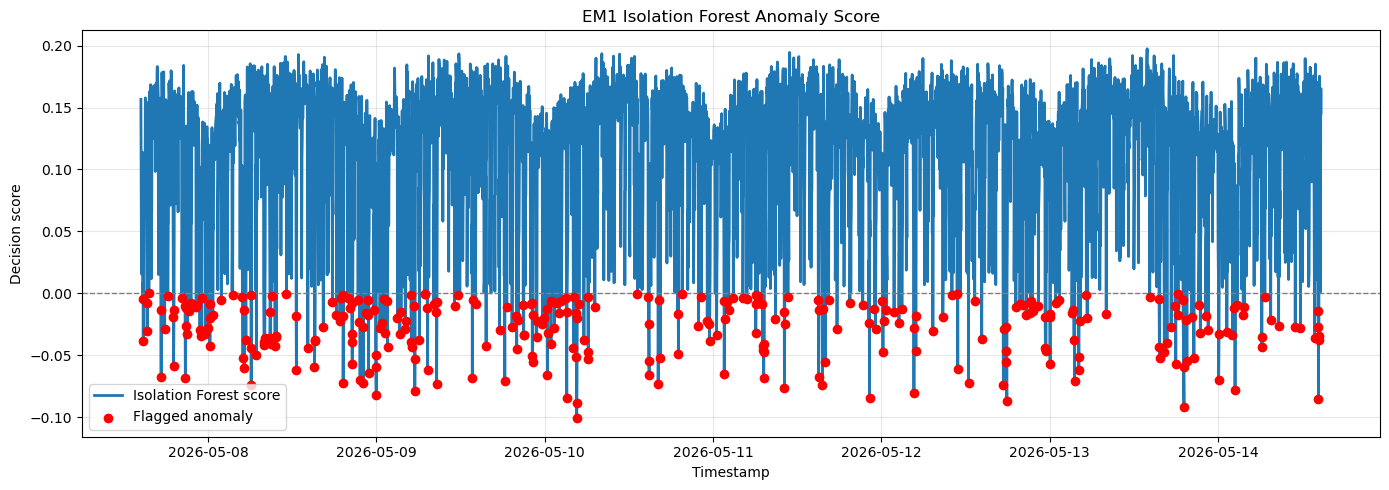

In [20]:
plt.figure(figsize=(14, 5))
plt.plot(dataset["Timestamp"], dataset["AnomalyScore"], label="Isolation Forest score", linewidth=2)
plt.scatter(
    dataset.loc[dataset["IsAnomaly"] == 1, "Timestamp"],
    dataset.loc[dataset["IsAnomaly"] == 1, "AnomalyScore"],
    color="red",
    label="Flagged anomaly",
    zorder=3,
)
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.title("EM1 Isolation Forest Anomaly Score")
plt.xlabel("Timestamp")
plt.ylabel("Decision score")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()




## 9. Plot cycle time with anomaly markers



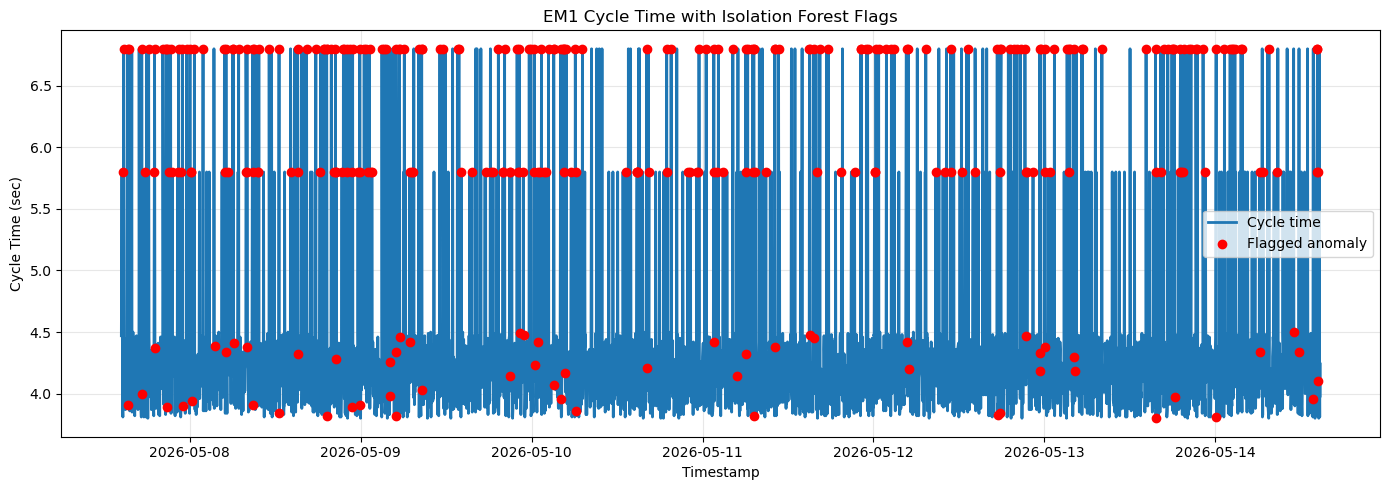

In [21]:
plt.figure(figsize=(14, 5))
plt.plot(dataset["Timestamp"], dataset["CycleTime_sec"], label="Cycle time", linewidth=2)
plt.scatter(
    dataset.loc[dataset["IsAnomaly"] == 1, "Timestamp"],
    dataset.loc[dataset["IsAnomaly"] == 1, "CycleTime_sec"],
    color="red",
    label="Flagged anomaly",
    zorder=3,
)
plt.title("EM1 Cycle Time with Isolation Forest Flags")
plt.xlabel("Timestamp")
plt.ylabel("Cycle Time (sec)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()




## 10. Compare anomaly rate by machine state



In [22]:
state_summary = (
    dataset.groupby("Status")["IsAnomaly"]
    .agg(["count", "sum", "mean"])
    .rename(columns={"count": "Rows", "sum": "AnomalyCount", "mean": "AnomalyRate"})
    .sort_values("AnomalyRate", ascending=False)
)

state_summary




,Rows,AnomalyCount,AnomalyRate
Status,,,
alarm,465,256,0.550538
idle,227,32,0.140969
running,3236,27,0.008344


## 11. Evaluate early-warning behavior against upcoming alarms



In [23]:
evaluation_df = dataset.copy()
evaluation_df["PredictedWarning"] = evaluation_df["IsAnomaly"]

print(
    classification_report(
        evaluation_df["UpcomingAlarm_10min"],
        evaluation_df["PredictedWarning"],
        digits=4
    )
)
print(
    "ROC-AUC using inverted anomaly score as risk:",
    f"{roc_auc_score(evaluation_df['UpcomingAlarm_10min'], -evaluation_df['AnomalyScore']):.4f}"
)




              precision    recall  f1-score   support

           0     0.7786    0.9214    0.8440      3053
           1     0.2381    0.0857    0.1261       875

    accuracy                         0.7352      3928
   macro avg     0.5083    0.5036    0.4850      3928
weighted avg     0.6582    0.7352    0.6841      3928

ROC-AUC using inverted anomaly score as risk: 0.4916


## 12. Confusion matrix for early warning



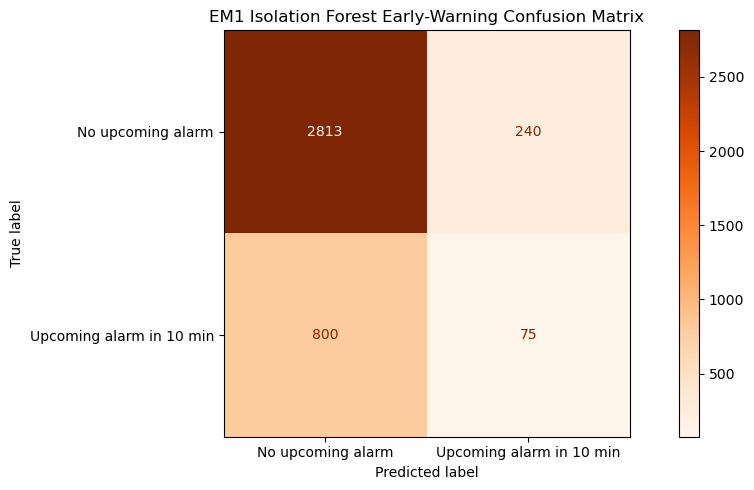

In [26]:
fig, ax = plt.subplots(figsize=(10, 5))
ConfusionMatrixDisplay.from_predictions(
    evaluation_df["UpcomingAlarm_10min"],
    evaluation_df["PredictedWarning"],
    display_labels=["No upcoming alarm", "Upcoming alarm in 10 min"],
    cmap="Oranges",
    ax=ax,
)
ax.set_title("EM1 Isolation Forest Early-Warning Confusion Matrix")
plt.tight_layout()
plt.show()




## 13. Risk score view against future alarms



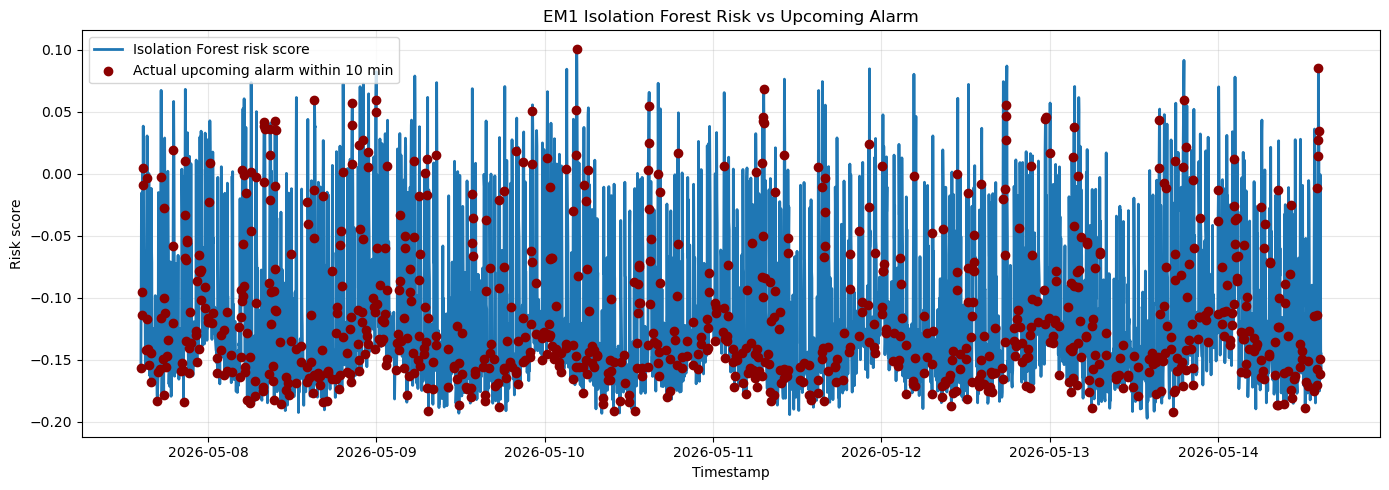

In [27]:
plt.figure(figsize=(14, 5))
plt.plot(
    evaluation_df["Timestamp"],
    -evaluation_df["AnomalyScore"],
    label="Isolation Forest risk score",
    linewidth=2,
)
plt.scatter(
    evaluation_df.loc[evaluation_df["UpcomingAlarm_10min"] == 1, "Timestamp"],
    (-evaluation_df.loc[evaluation_df["UpcomingAlarm_10min"] == 1, "AnomalyScore"]),
    color="darkred",
    label="Actual upcoming alarm within 10 min",
    zorder=3,
)
plt.title("EM1 Isolation Forest Risk vs Upcoming Alarm")
plt.xlabel("Timestamp")
plt.ylabel("Risk score")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()




## Notes

This is intentionally a simple example for GitHub and experimentation.
Good next steps would be:
- compare Isolation Forest flags with `AnomalyLog`
- tune `contamination`, warning threshold, and feature set
- score each sensor independently
- use a longer prediction horizon such as 15 or 30 minutes
- build a hybrid workflow with anomaly detection plus alarm classification
